<h1 style='color:#5BC0EB; font-weight:800; font-size:1.9em; margin-bottom:0.3em'>Reconstrucción de curvas desde píxeles</h1>
<h3 style='color:#A8D8EA; font-weight:400; font-size:1.1em; margin-top:0'>Aplicar el sistema adaptativo a los datos pixelizados y comparar con el target</h3>
<p style='color:#b0b0b0; font-size:0.92em'>El selector entrenado en <em>sistema_adaptativo</em> recomienda el método de ajuste a partir de descriptores geométricos. 

Aquí usaremos eso pero sobre los datos crudos pixelizados (5 escalas por curva), reconstruimos cada curva y la comparamos contra el target.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
import joblib, warnings, time
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10})

PALETTE = {'polinomio': '#2E86AB', 'gaussianas': '#A23B72', 'spline': '#F18F01'}
AZUL, NARANJA, AZUL_PAL = '#5BC0EB', '#F18F01', '#A8D8EA'
SCALES = [10, 15, 18, 21, 25]

In [2]:
ROOT = Path.cwd().parent
DATA_T = ROOT / 'datos' / 'target'
DATA_P = ROOT / 'datos' / 'pixel_curves'
MODELOS = ROOT / 'modelos'

_ck = joblib.load(MODELOS / 'modelo_seleccion_metodo.pkl')
selector = _ck['pipeline']
FEATS    = _ck['features']
CLASES   = _ck['classes']
print(f'Selector cargado. Clases: {CLASES}')
print(f'Features ({len(FEATS)}): {FEATS}')

def leer_target(cid):
    return pd.read_csv(DATA_T / f'curve_{cid:04d}.txt', header=None, names=['x', 'y']).sort_values('x').reset_index(drop=True)

def leer_pixel_real(cid, escala):
    # El factor de escala multiplica las coordenadas enteras del píxel; al dividir volvemos a unidades reales comparables al target.
    d = pd.read_csv(DATA_P / f'curve_{cid:04d}_X{escala}.txt', sep=' ', header=None, names=['x', 'y'])
    f = escala / 10.0
    d['x'] = d['x'] / f
    d['y'] = d['y'] / f
    return d.sort_values('x').reset_index(drop=True)

Selector cargado. Clases: ['gaussianas', 'polinomio', 'spline']
Features (12): ['n_inflection', 'n_maxima', 'fft_n_peaks', 'aspect_ratio', 'slope_mean', 'curvature_max', 'angle_range', 'monotonicity_score', 'curvature_mean', 'curvature_q95', 'fft_spectral_centroid', 'y_range']


In [3]:
def compute_pixel_features(dc):
    x = dc['x'].values.astype(float); y = dc['y'].values.astype(float); n = len(x)
    if n < 5: return {}
    dy_ = np.diff(y); yr = float(y.max() - y.min()); xr = float(x.max() - x.min())
    yf = np.abs(np.fft.rfft(y - y.mean())); fr = np.fft.rfftfreq(n); yf[0] = 0
    yfmax = yf.max()
    if yfmax > 0:
        tp = (yf**2).sum() + 1e-12
        cent = float((fr * yf**2).sum() / tp)
        pks, _ = find_peaks(yf, height=0.1*yfmax); nfp = float(len(pks))
    else:
        cent = nfp = 0.0
    W = max(5, n // 20); km = []
    for i in range(0, n - W, max(1, W // 2)):
        sx, sy = x[i:i+W], y[i:i+W]
        if len(sx) < 3: continue
        dy2 = np.gradient(sy, sx); d2 = np.gradient(dy2, sx)
        km.append(float(np.mean(np.abs(d2) / (1 + dy2**2)**1.5)))
    loc_comp = float(np.std(km)) if len(km) > 1 else 0.0
    pks_y, _ = find_peaks(y); vals_y, _ = find_peaks(-y)
    f = {'y_range': yr, 'x_range': xr, 'aspect_ratio': yr / (xr + 1e-9),
         'y_skewness': float(stats.skew(y)), 'y_kurtosis': float(stats.kurtosis(y)),
         'monotonicity_score': float((dy_ > 0).sum() / max(len(dy_), 1)),
         'local_complexity': loc_comp, 'fft_spectral_centroid': cent,
         'fft_n_peaks': nfp, 'n_maxima': float(len(pks_y)), 'n_minima': float(len(vals_y))}
    sl = np.diff(y) / (np.diff(x) + 1e-9)
    f['slope_mean']   = float(np.mean(np.abs(sl)))
    f['angle_range']  = float(np.ptp(np.arctan(sl)))
    f['n_inflection'] = float(np.sum(np.diff(np.sign(np.diff(y))) != 0))
    g1 = np.gradient(y, x); g2 = np.gradient(g1, x)
    curv = np.abs(g2) / (1 + g1**2)**1.5
    f['curvature_mean'] = float(np.mean(curv))
    f['curvature_max']  = float(np.max(curv))
    f['curvature_q95']  = float(np.quantile(curv, 0.95))
    return f

def predecir_metodo(x, y):
    raw = compute_pixel_features(pd.DataFrame({'x': x, 'y': y}))
    if not raw: return None, 0.0
    row = np.array([raw.get(f, 0.0) for f in FEATS]).reshape(1, -1)
    row = np.nan_to_num(row)
    probs = selector.predict_proba(row)[0]
    k = int(np.argmax(probs))
    return selector.classes_[k], float(probs[k])

def _gauss_sum(x, *params):
    n = len(params) // 3; y = np.zeros_like(x, dtype=float)
    for i in range(n):
        A, mu, sig = params[3*i], params[3*i+1], params[3*i+2]
        y += A * np.exp(-(x - mu)**2 / (2 * sig**2 + 1e-9))
    return y

def fit_polinomio(xp, yp, x_eval, deg=10):
    deg = min(deg, len(xp) - 1)
    coef = np.polyfit(xp, yp, deg)
    return np.polyval(coef, x_eval)

def fit_spline(xp, yp, x_eval):
    xp_u, idx = np.unique(xp, return_index=True); yp_u = yp[idx]
    if len(xp_u) < 5: return fit_polinomio(xp, yp, x_eval, deg=6)
    s = UnivariateSpline(xp_u, yp_u, k=min(3, len(xp_u)-1), s=len(xp_u))
    return s(np.clip(x_eval, xp_u.min(), xp_u.max()))

def fit_gaussianas(xp, yp, x_eval, n_max=8):
    pks, _ = find_peaks(yp, height=yp.mean())
    n = min(max(len(pks), 1), n_max)
    p0 = []
    if len(pks):
        for pk in pks[:n]:
            p0 += [float(yp[pk]), float(xp[pk]), float((xp[-1]-xp[0]) / (2*n+1))]
    else:
        p0 = [float(yp.max()), float(xp.mean()), float((xp[-1]-xp[0]) / 4)]
    try:
        popt, _ = curve_fit(lambda x, *p: _gauss_sum(x, *p), xp, yp, p0=p0, maxfev=4000)
        return _gauss_sum(x_eval, *popt)
    except Exception:
        return fit_polinomio(xp, yp, x_eval, deg=10)

FITTERS = {'polinomio': fit_polinomio, 'gaussianas': fit_gaussianas, 'spline': fit_spline}

def reconstruir(cid, escala, x_eval=None):
    pix = leer_pixel_real(cid, escala)
    tgt = leer_target(cid)
    if x_eval is None: x_eval = tgt['x'].values
    metodo, prob = predecir_metodo(pix['x'].values, pix['y'].values)
    if metodo is None: return None
    y_hat  = FITTERS[metodo](pix['x'].values, pix['y'].values, x_eval)
    y_true = np.interp(x_eval, tgt['x'].values, tgt['y'].values)
    res = y_true - y_hat
    ss_res = (res**2).sum(); ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {'metodo': metodo, 'prob': prob, 'x_eval': x_eval,
            'y_hat': y_hat, 'y_true': y_true,
            'r2': float(r2),
            'rmse': float(np.sqrt((res**2).mean())),
            'mae': float(np.abs(res).mean()),
            'max_ae': float(np.abs(res).max())}

print('Funciones de descriptores, ajuste y reconstrucción listas.')

Funciones de descriptores, ajuste y reconstrucción listas.


<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 1 : Una curva, cinco escalas</h2>
<p style='color:#b0b0b0; font-size:0.92em'>Antes del análisis masivo conviene mirar el caso individual: cómo se ve la curva pixelizada en cada escala, qué método elige el selector con esos datos crudos y qué tan cerca queda la reconstrucción del target. Sirve de control visual de que el pipeline funciona como debe.</p>

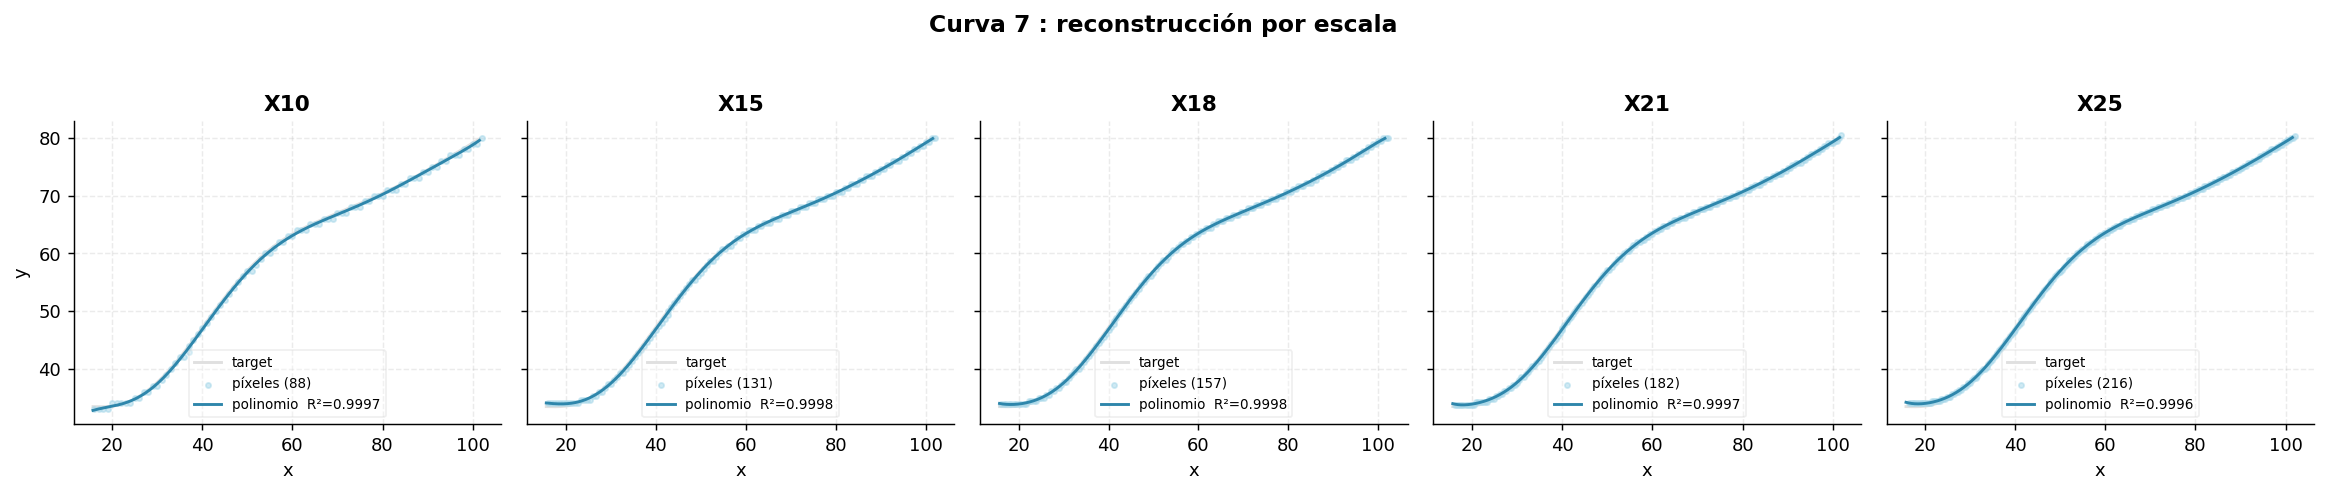

In [4]:
CID_DEMO = 7  # cambiar libremente
tgt_demo = leer_target(CID_DEMO)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, esc in zip(axes, SCALES):
    rec = reconstruir(CID_DEMO, esc)
    pix = leer_pixel_real(CID_DEMO, esc)
    ax.plot(tgt_demo['x'], tgt_demo['y'], color='#e0e0e0', lw=1.6, label='target', zorder=2)
    ax.scatter(pix['x'], pix['y'], s=8, color=AZUL_PAL, alpha=0.55, label=f'píxeles ({len(pix)})', zorder=3)
    ax.plot(rec['x_eval'], rec['y_hat'], color=PALETTE[rec['metodo']], lw=1.6,
            label=f"{rec['metodo']}  R²={rec['r2']:.4f}", zorder=4)
    ax.set_title(f'X{esc}', pad=6); ax.set_xlabel('x')
    ax.legend(fontsize=7.5, loc='lower center', framealpha=0.3)
axes[0].set_ylabel('y')
fig.suptitle(f'Curva {CID_DEMO} : reconstrucción por escala', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 2 : Reconstrucción masiva</h2>
<p style='color:#b0b0b0; font-size:0.92em'>Pasamos las 500 curvas por las cinco escalas (2 500 reconstrucciones). Para que el R² sea comparable entre todas, evaluamos siempre sobre la malla del target. Lo que sigue es un dataframe con el método elegido por el selector, las métricas de error frente al target y el número de píxeles disponibles en cada escala.</p>

In [5]:
ids_disp = sorted(int(p.stem.split('_')[1]) for p in DATA_T.glob('curve_*.txt'))
print(f'Curvas disponibles: {len(ids_disp)}  |  escalas: {SCALES}')

rows = []; t0 = time.time(); fallos = 0
for k, cid in enumerate(ids_disp, 1):
    for esc in SCALES:
        try:
            r = reconstruir(cid, esc)
            if r is None: fallos += 1; continue
            rows.append({'curva': cid, 'escala': esc, 'metodo': r['metodo'],
                         'prob': r['prob'], 'r2': r['r2'], 'rmse': r['rmse'],
                         'mae': r['mae'], 'max_ae': r['max_ae'],
                         'n_pix': int(len(leer_pixel_real(cid, esc)))})
        except Exception:
            fallos += 1
    if k % 50 == 0:
        print(f'  procesadas {k}/{len(ids_disp)} curvas  ({time.time()-t0:.1f}s)')

res_df = pd.DataFrame(rows)
print(f'\nReconstrucciones OK: {len(res_df)}  |  fallos: {fallos}  |  tiempo: {time.time()-t0:.1f}s')
res_df.head()

Curvas disponibles: 500  |  escalas: [10, 15, 18, 21, 25]
  procesadas 50/500 curvas  (20.2s)
  procesadas 100/500 curvas  (43.9s)
  procesadas 150/500 curvas  (71.9s)
  procesadas 200/500 curvas  (108.5s)
  procesadas 250/500 curvas  (131.4s)
  procesadas 300/500 curvas  (152.4s)
  procesadas 350/500 curvas  (173.2s)
  procesadas 400/500 curvas  (197.4s)
  procesadas 450/500 curvas  (219.5s)
  procesadas 500/500 curvas  (248.6s)

Reconstrucciones OK: 2500  |  fallos: 0  |  tiempo: 248.6s


,curva,escala,metodo,prob,r2,rmse,mae,max_ae,n_pix
0,1,10,gaussianas,0.818182,0.983182,2.061706,1.463081,8.376652,344
1,1,15,gaussianas,0.818182,0.983051,2.069722,1.514170,8.478174,517
2,1,18,gaussianas,0.818182,0.982757,2.087602,1.548033,8.535796,619
3,1,21,gaussianas,0.818182,0.982555,2.099768,1.569844,8.605970,721
4,1,25,gaussianas,0.818182,0.982223,2.119651,1.598338,8.607783,860


In [6]:
print('Resumen global (las 2 500 reconstrucciones)')
display(res_df[['r2', 'rmse', 'mae', 'max_ae']].agg(['mean', 'median', 'std', 'min', 'max']).T.round(4))

print('\nPromedios por escala')
display(res_df.groupby('escala')[['r2', 'rmse', 'mae', 'max_ae']].mean().round(4))

print('\nPromedios por método elegido por el selector')
display(res_df.groupby('metodo')[['r2', 'rmse', 'mae', 'max_ae']].agg(['mean', 'count']).round(4))

print('\nDistribución de método por escala (% del total de cada escala)')
dist = (res_df.groupby(['escala', 'metodo']).size().unstack(fill_value=0)
        .div(res_df.groupby('escala').size(), axis=0).round(3) * 100)
display(dist)

Resumen global (las 2 500 reconstrucciones)


,mean,median,std,min,max
r2,0.9522,0.9918,0.1855,-4.7377,0.9999
rmse,2.0396,1.2270,2.3845,0.1842,55.2147
mae,1.6558,0.9703,2.0456,0.1503,50.1729
max_ae,5.2275,3.4416,5.2315,0.3499,84.9585



Promedios por escala


,r2,rmse,mae,max_ae
escala,,,,
10,0.9490,2.1656,1.7560,5.4403
15,0.9623,1.8866,1.5214,4.8641
18,0.9545,2.0133,1.6356,5.1796
21,0.9602,1.9119,1.5444,5.0315
25,0.9352,2.2208,1.8216,5.6218



Promedios por método elegido por el selector


r2          rmse           mae        max_ae      
              mean count    mean count    mean count    mean count
metodo                                                            
gaussianas  0.9246  1527  2.8357  1527  2.3007  1527  7.3233  1527
polinomio   0.9980   549  0.5279   549  0.4445   549  1.1886   549
spline      0.9923   424  1.1301   424  0.9016   424  2.9089   424


Distribución de método por escala (% del total de cada escala)


metodo,gaussianas,polinomio,spline
escala,,,
10,55.6,28.8,15.6
15,56.8,27.0,16.2
18,60.6,21.6,17.8
21,63.8,19.0,17.2
25,68.6,13.4,18.0


<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 3: Visualizaciones</h2>


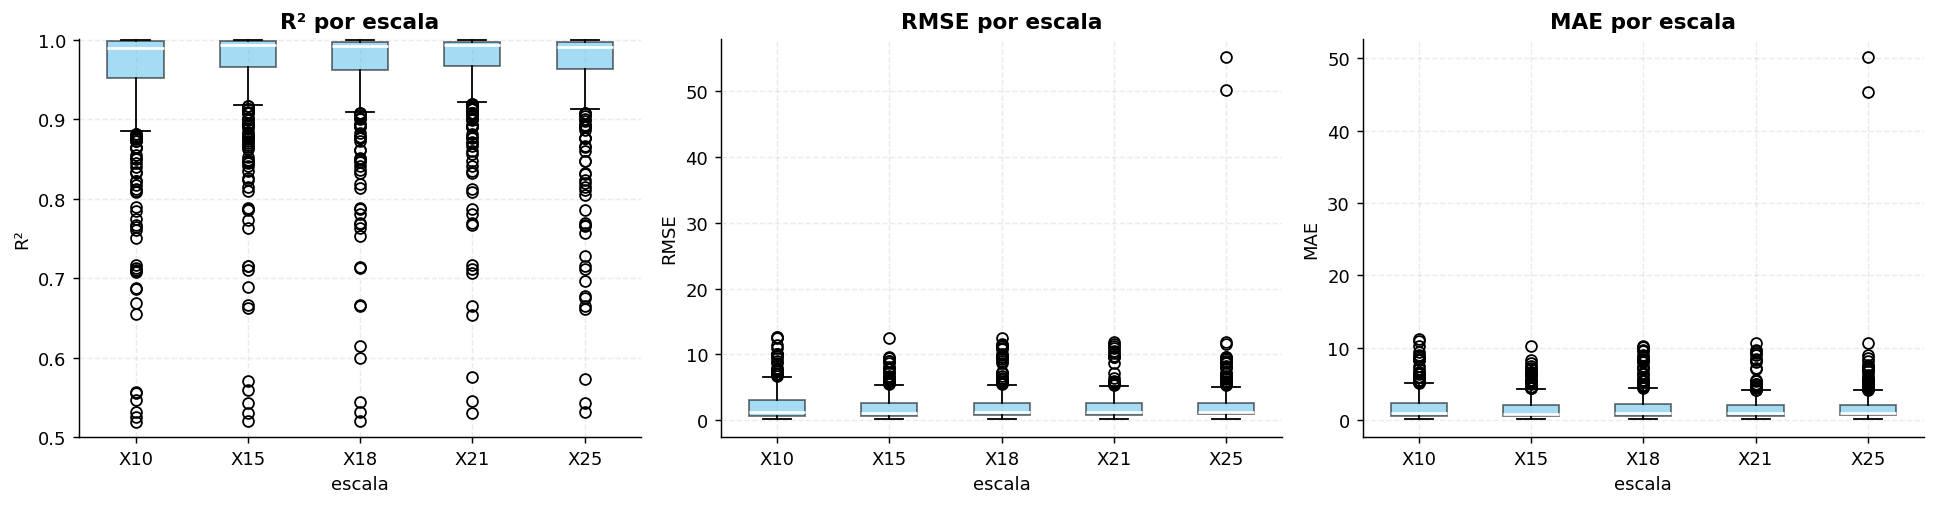

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (m, t) in zip(axes, [('r2', 'R²'), ('rmse', 'RMSE'), ('mae', 'MAE')]):
    data = [res_df.loc[res_df.escala == e, m].values for e in SCALES]
    bp = ax.boxplot(data, labels=[f'X{e}' for e in SCALES], patch_artist=True,
                    medianprops=dict(color='white', lw=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor(AZUL); patch.set_alpha(0.55)
    ax.set_title(f'{t} por escala'); ax.set_xlabel('escala'); ax.set_ylabel(t)
    if m == 'r2':
        ax.set_ylim(max(0.5, res_df.r2.quantile(0.01) - 0.02), 1.001)
plt.tight_layout(); plt.show()

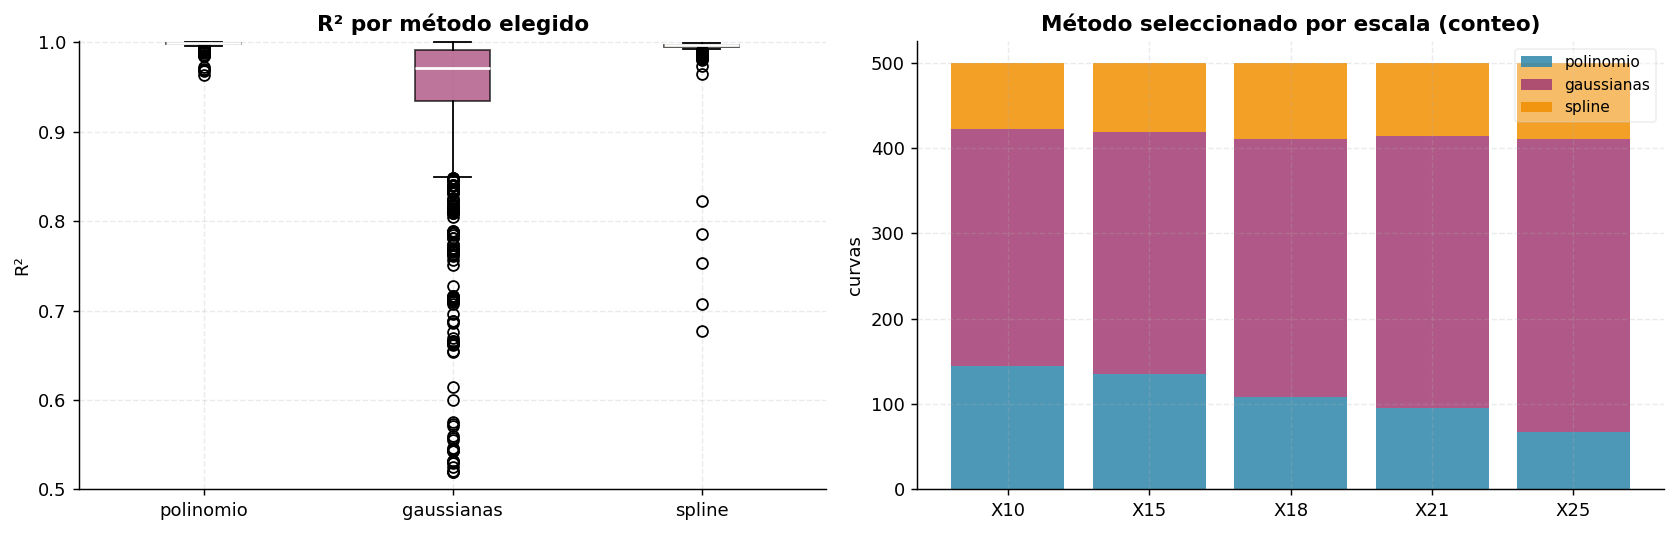

In [8]:
metodos_ord = [m for m in ['polinomio', 'gaussianas', 'spline'] if m in res_df.metodo.unique()]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

data_r2 = [res_df.loc[res_df.metodo == m, 'r2'].values for m in metodos_ord]
bp = axes[0].boxplot(data_r2, labels=metodos_ord, patch_artist=True,
                     medianprops=dict(color='white', lw=1.5))
for patch, m in zip(bp['boxes'], metodos_ord):
    patch.set_facecolor(PALETTE[m]); patch.set_alpha(0.7)
axes[0].set_title('R² por método elegido'); axes[0].set_ylabel('R²')
axes[0].set_ylim(max(0.5, res_df.r2.quantile(0.01) - 0.02), 1.001)

counts = res_df.groupby(['escala', 'metodo']).size().unstack(fill_value=0)
bottom = np.zeros(len(counts))
for m in metodos_ord:
    if m in counts.columns:
        axes[1].bar([f'X{e}' for e in counts.index], counts[m].values,
                    bottom=bottom, color=PALETTE[m], alpha=0.85, label=m)
        bottom += counts[m].values
axes[1].set_title('Método seleccionado por escala (conteo)')
axes[1].set_ylabel('curvas'); axes[1].legend(fontsize=8.5, framealpha=0.3)
plt.tight_layout(); plt.show()

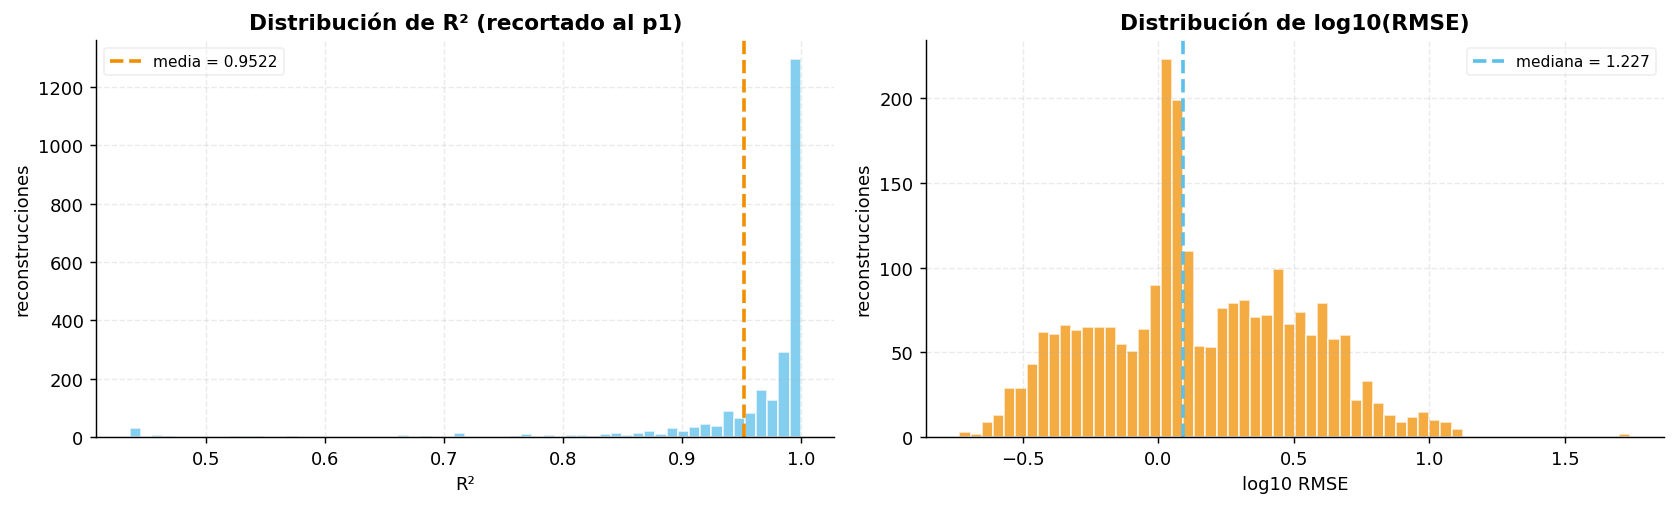

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(res_df.r2.clip(lower=res_df.r2.quantile(0.01)), bins=60,
             color=AZUL, alpha=0.75, edgecolor='white')
axes[0].axvline(res_df.r2.mean(), color=NARANJA, lw=2, ls='--',
                label=f'media = {res_df.r2.mean():.4f}')
axes[0].set_title('Distribución de R² (recortado al p1)')
axes[0].set_xlabel('R²'); axes[0].set_ylabel('reconstrucciones')
axes[0].legend(fontsize=8.5, framealpha=0.3)

axes[1].hist(np.log10(res_df.rmse.clip(lower=1e-6)), bins=60,
             color=NARANJA, alpha=0.75, edgecolor='white')
axes[1].axvline(np.log10(res_df.rmse.median()), color=AZUL, lw=2, ls='--',
                label=f'mediana = {res_df.rmse.median():.3f}')
axes[1].set_title('Distribución de log10(RMSE)')
axes[1].set_xlabel('log10 RMSE'); axes[1].set_ylabel('reconstrucciones')
axes[1].legend(fontsize=8.5, framealpha=0.3)
plt.tight_layout(); plt.show()

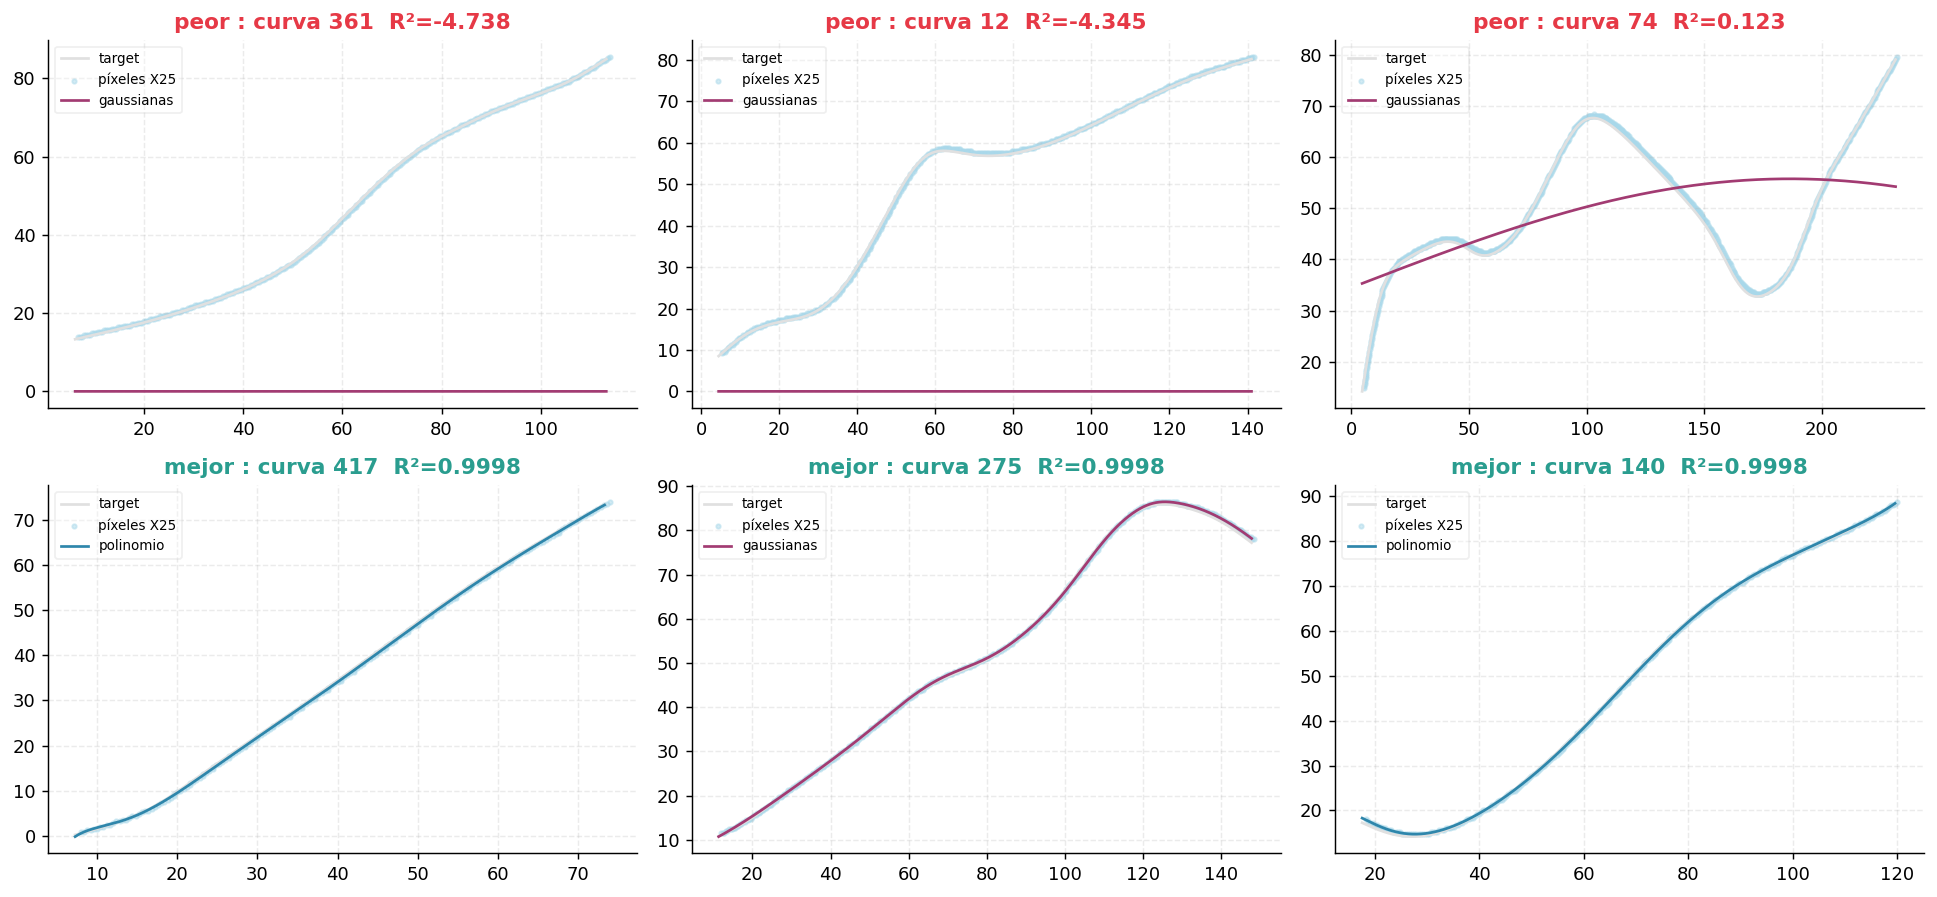

In [10]:
by_curve = res_df.groupby('curva').r2.mean().sort_values()
worst_ids = by_curve.head(3).index.tolist()
best_ids  = by_curve.tail(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, cid in enumerate(worst_ids):
    ax = axes[0, col]; esc = 25
    rec = reconstruir(cid, esc); pix = leer_pixel_real(cid, esc); tgt = leer_target(cid)
    ax.plot(tgt['x'], tgt['y'], color='#e0e0e0', lw=1.5, label='target')
    ax.scatter(pix['x'], pix['y'], s=6, color=AZUL_PAL, alpha=0.5, label='píxeles X25')
    ax.plot(rec['x_eval'], rec['y_hat'], color=PALETTE[rec['metodo']], lw=1.5, label=rec['metodo'])
    ax.set_title(f"peor : curva {cid}  R²={rec['r2']:.3f}", color='#E63946')
    ax.legend(fontsize=7.5, framealpha=0.3)

for col, cid in enumerate(best_ids):
    ax = axes[1, col]; esc = 25
    rec = reconstruir(cid, esc); pix = leer_pixel_real(cid, esc); tgt = leer_target(cid)
    ax.plot(tgt['x'], tgt['y'], color='#e0e0e0', lw=1.5, label='target')
    ax.scatter(pix['x'], pix['y'], s=6, color=AZUL_PAL, alpha=0.5, label='píxeles X25')
    ax.plot(rec['x_eval'], rec['y_hat'], color=PALETTE[rec['metodo']], lw=1.5, label=rec['metodo'])
    ax.set_title(f"mejor : curva {cid}  R²={rec['r2']:.4f}", color='#2A9D8F')
    ax.legend(fontsize=7.5, framealpha=0.3)
plt.tight_layout(); plt.show()

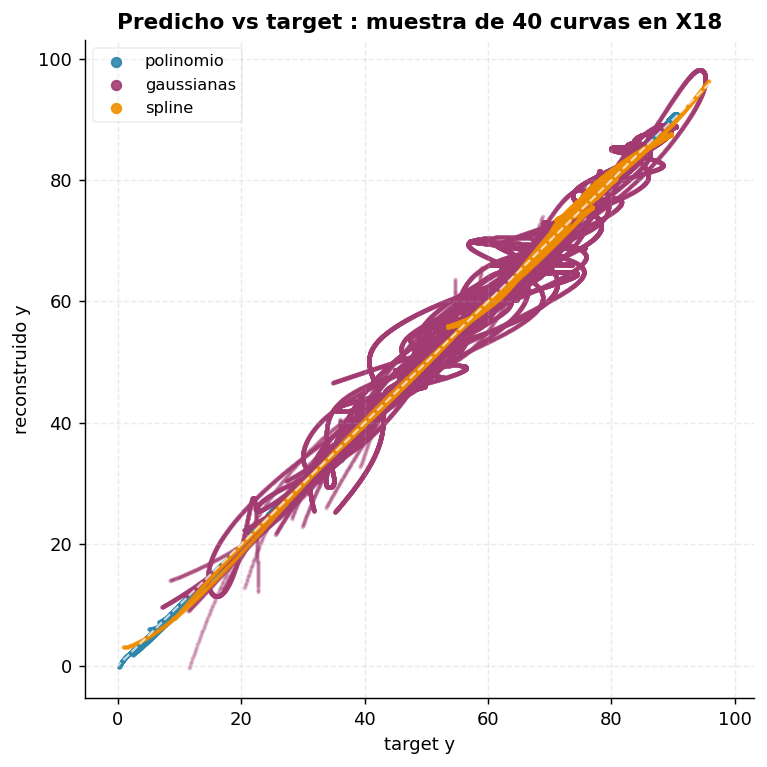

In [11]:
sample_ids = res_df.curva.drop_duplicates().sample(40, random_state=7).tolist()
all_true, all_pred, all_method = [], [], []
for cid in sample_ids:
    rec = reconstruir(cid, 18)
    if rec is None: continue
    all_true.append(rec['y_true']); all_pred.append(rec['y_hat'])
    all_method += [rec['metodo']] * len(rec['y_true'])
yt = np.concatenate(all_true); yp = np.concatenate(all_pred); mt = np.array(all_method)

fig, ax = plt.subplots(figsize=(6, 6))
for m in metodos_ord:
    msk = mt == m
    if msk.sum() == 0: continue
    ax.scatter(yt[msk], yp[msk], s=2, alpha=0.18, color=PALETTE[m], label=m)
lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
ax.plot([lo, hi], [lo, hi], color='white', lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('target y'); ax.set_ylabel('reconstruido y')
ax.set_title(f'Predicho vs target : muestra de {len(sample_ids)} curvas en X18')
leg = ax.legend(fontsize=9, framealpha=0.3)
for h in getattr(leg, 'legend_handles', []):
    h.set_alpha(0.9); h.set_sizes([28])
plt.tight_layout(); plt.show()

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Lectura de los KPIs</h4>

<p style='color:#b0b0b0; font-size:0.92em'>El R² medio sobre las 2 500 reconstrucciones es <strong>0.952</strong> y la mediana <strong>0.992</strong>. La distancia entre las dos es la pista más importante: la mayoría de las curvas se reconstruyen casi perfectas, pero hay una cola de fallos serios (mínimo R² = -4.74) que arrastra la media.</p>

<p style='color:#b0b0b0; font-size:0.92em'>Por escala el R² medio se mueve entre 0.935 y 0.962, prácticamente plano. Más píxeles no ayudan, X25 es incluso la peor de todas. El cuello de botella no es la densidad del muestreo sino la elección de método.</p>

<p style='color:#b0b0b0; font-size:0.92em'>Cuando el selector elige <strong>polinomio</strong> el R² medio es 0.998 y cuando elige <strong>spline</strong> es 0.992 : los dos casi perfectos. El problema es que elige <strong>gaussianas</strong> el 61% de las veces y ahí el R² medio cae a 0.925 con casos catastróficos. La distribución también se inclina con la escala: a más píxeles más se va a gaussianas (de 56% en X10 a 69% en X25), exactamente la decisión equivocada.</p>

<blockquote style='border-left:4px solid #F18F01; padding:10px 16px; background:rgba(241,143,1,0.10); color:#e8c97a; font-size:0.92em'>
La conclusión accionable es que el selector, entrenado con descriptores calculados sobre el target de alta precisión, sobre-selecciona gaussianas cuando lo aplicamos a píxeles. Reentrenarlo con descriptores calculados directamente sobre los datos pixelizados (con sus picos espurios y ruido propio) probablemente cierra la brecha.
</blockquote>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 3.5 : ¿Dónde falla el sistema y por qué?</h2>
<p style='color:#b0b0b0; font-size:0.92em'>La mediana es altísima pero la media baja por una cola de casos malos. Aquí los aislamos: definimos como fallo toda reconstrucción con R² &lt; 0.5 y miramos qué método los produce, en qué escalas se concentran, qué descriptores los caracterizan y qué pinta tienen para entender el porqué.</p>

In [12]:
UMBRAL_FALLO = 0.5
res_df['es_fallo'] = res_df['r2'] < UMBRAL_FALLO
n_fallos = int(res_df['es_fallo'].sum())
print(f'Fallos (R² < {UMBRAL_FALLO}): {n_fallos} / {len(res_df)}  ({n_fallos / len(res_df):.1%})')

print('\nFallos por método elegido')
tab_metodo = (res_df.groupby('metodo')
              .agg(n=('r2', 'size'), n_fallos=('es_fallo', 'sum'),
                   tasa_fallo=('es_fallo', 'mean'),
                   r2_medio=('r2', 'mean'),
                   r2_mediana=('r2', 'median'))
              .round(4).sort_values('tasa_fallo', ascending=False))
display(tab_metodo)

print('\nFallos por escala')
tab_escala = (res_df.groupby('escala')
              .agg(n=('r2', 'size'), n_fallos=('es_fallo', 'sum'),
                   tasa_fallo=('es_fallo', 'mean'))
              .round(4))
display(tab_escala)

print('\nCurvas que fallan en al menos una escala')
fail_per_curve = res_df.groupby('curva')['es_fallo'].sum()
print(f'  curvas con 0 fallos:  {(fail_per_curve == 0).sum()}')
print(f'  curvas con 1-2 fallos: {((fail_per_curve >= 1) & (fail_per_curve <= 2)).sum()}')
print(f'  curvas con 3-4 fallos: {((fail_per_curve >= 3) & (fail_per_curve <= 4)).sum()}')
print(f'  curvas con 5 fallos (todas las escalas): {(fail_per_curve == 5).sum()}')

Fallos (R² < 0.5): 40 / 2500  (1.6%)

Fallos por método elegido


,n,n_fallos,tasa_fallo,r2_medio,r2_mediana
metodo,,,,,
gaussianas,1527,40,0.0262,0.9246,0.9707
polinomio,549,0,0.0000,0.9980,0.9989
spline,424,0,0.0000,0.9923,0.9964



Fallos por escala


,n,n_fallos,tasa_fallo
escala,,,
10,500,8,0.016
15,500,4,0.008
18,500,10,0.020
21,500,8,0.016
25,500,10,0.020



Curvas que fallan en al menos una escala
  curvas con 0 fallos:  482
  curvas con 1-2 fallos: 12
  curvas con 3-4 fallos: 4
  curvas con 5 fallos (todas las escalas): 2


In [13]:
# Comparar descriptores de las curvas que fallan vs las que no.
# Calculamos descriptores sobre target (no sobre píxeles) para tener una sola fila por curva.
print('Calculando descriptores por curva (target)...')
desc_rows = []
for cid in fail_per_curve.index:
    feats = compute_pixel_features(leer_target(cid))
    feats['curva'] = cid
    feats['n_fallos'] = int(fail_per_curve.loc[cid])
    feats['perfil'] = 'falla' if fail_per_curve.loc[cid] >= 3 else 'ok'
    desc_rows.append(feats)
desc_df = pd.DataFrame(desc_rows)

cols_clave = ['n_inflection', 'n_maxima', 'fft_n_peaks', 'curvature_max',
              'curvature_q95', 'slope_mean', 'angle_range', 'aspect_ratio']
print('\nDescriptores: media en curvas que fallan vs curvas ok')
comp = desc_df.groupby('perfil')[cols_clave].mean().T.round(3)
comp['ratio'] = (comp['falla'] / comp['ok'].replace(0, np.nan)).round(2)
display(comp)

Calculando descriptores por curva (target)...

Descriptores: media en curvas que fallan vs curvas ok


perfil,falla,ok,ratio
n_inflection,4.167,4.209,0.99
n_maxima,2.167,2.328,0.93
fft_n_peaks,2.667,1.982,1.35
curvature_max,0.119,0.160,0.74
curvature_q95,0.080,0.100,0.80
slope_mean,0.466,0.668,0.70
angle_range,1.573,1.738,0.91
aspect_ratio,0.202,0.384,0.53


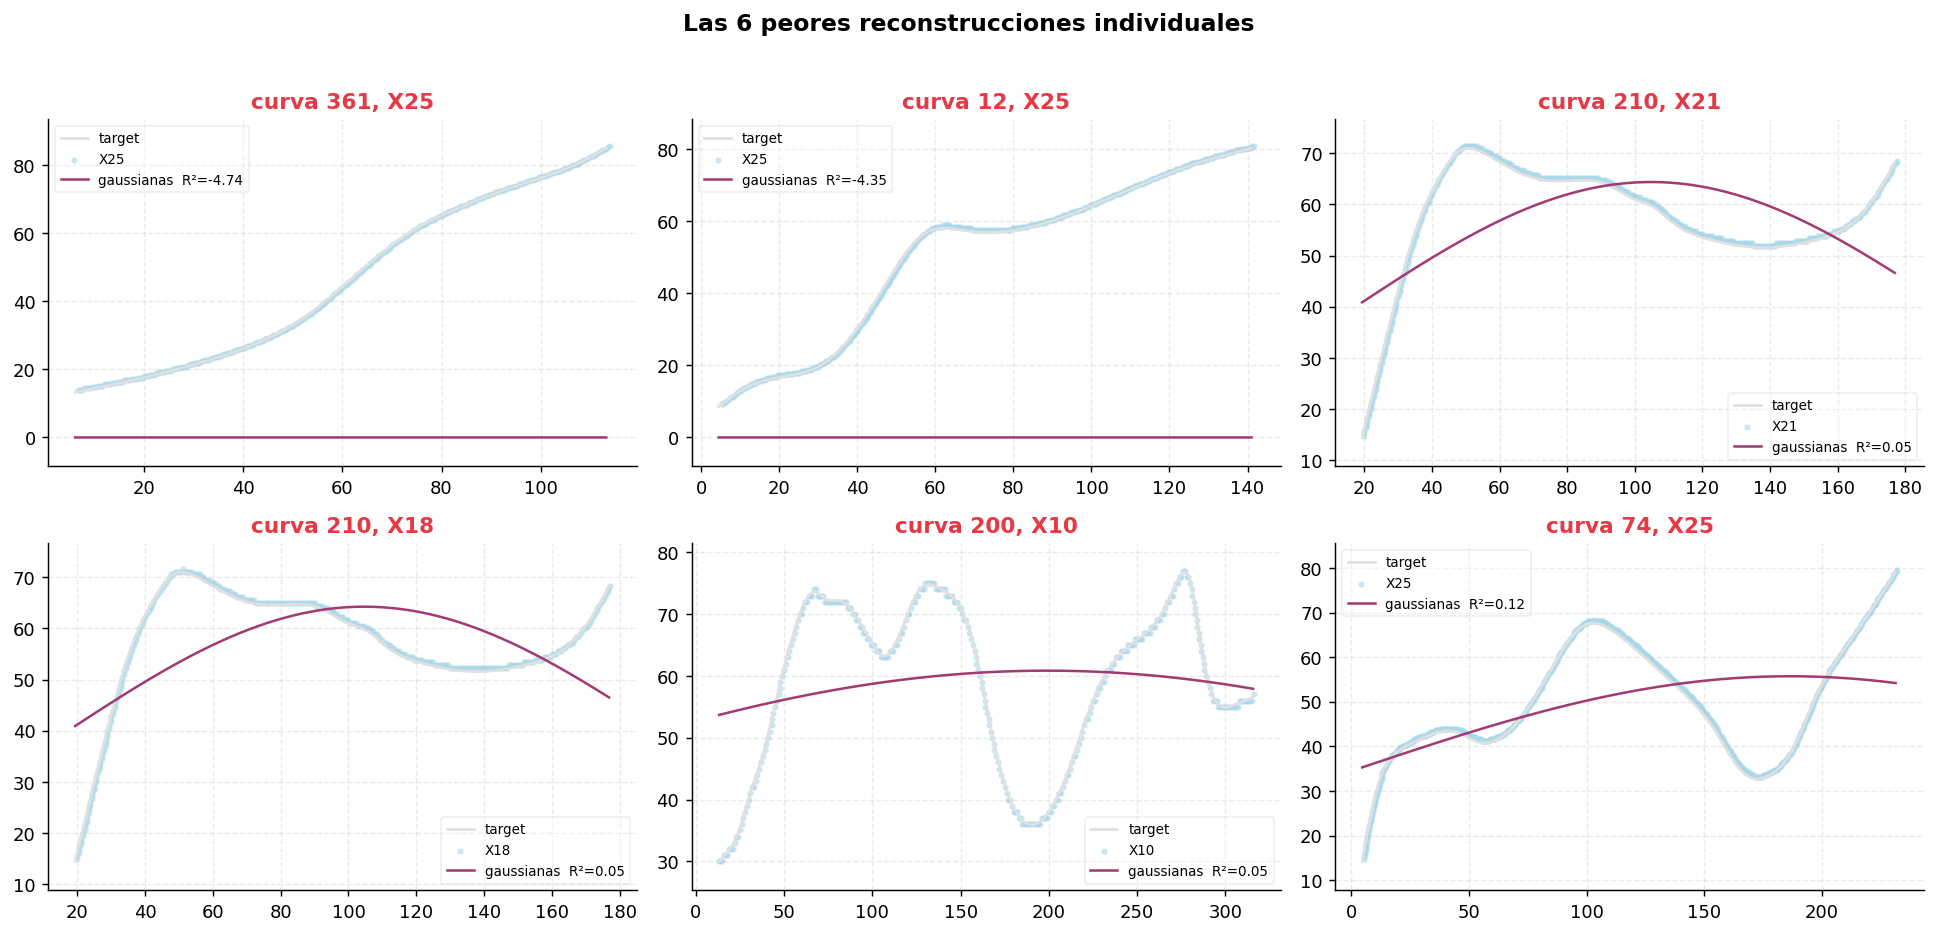

In [14]:
# Galería de fallos típicos: las 6 reconstrucciones individuales con peor R².
peores = res_df.sort_values('r2').head(6).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for k, row in peores.iterrows():
    ax = axes[k // 3, k % 3]
    cid, esc = int(row['curva']), int(row['escala'])
    rec = reconstruir(cid, esc)
    pix = leer_pixel_real(cid, esc); tgt = leer_target(cid)
    ax.plot(tgt['x'], tgt['y'], color='#e0e0e0', lw=1.5, label='target')
    ax.scatter(pix['x'], pix['y'], s=6, color=AZUL_PAL, alpha=0.5, label=f'X{esc}')
    ax.plot(rec['x_eval'], rec['y_hat'], color=PALETTE[rec['metodo']], lw=1.4,
            label=f"{rec['metodo']}  R²={rec['r2']:.2f}")
    y_lo = min(tgt['y'].min(), rec['y_hat'].min())
    y_hi = max(tgt['y'].max(), rec['y_hat'].max())
    pad = (y_hi - y_lo) * 0.1
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.set_title(f'curva {cid}, X{esc}', color='#E63946')
    ax.legend(fontsize=7.5, framealpha=0.3)
fig.suptitle('Las 6 peores reconstrucciones individuales', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

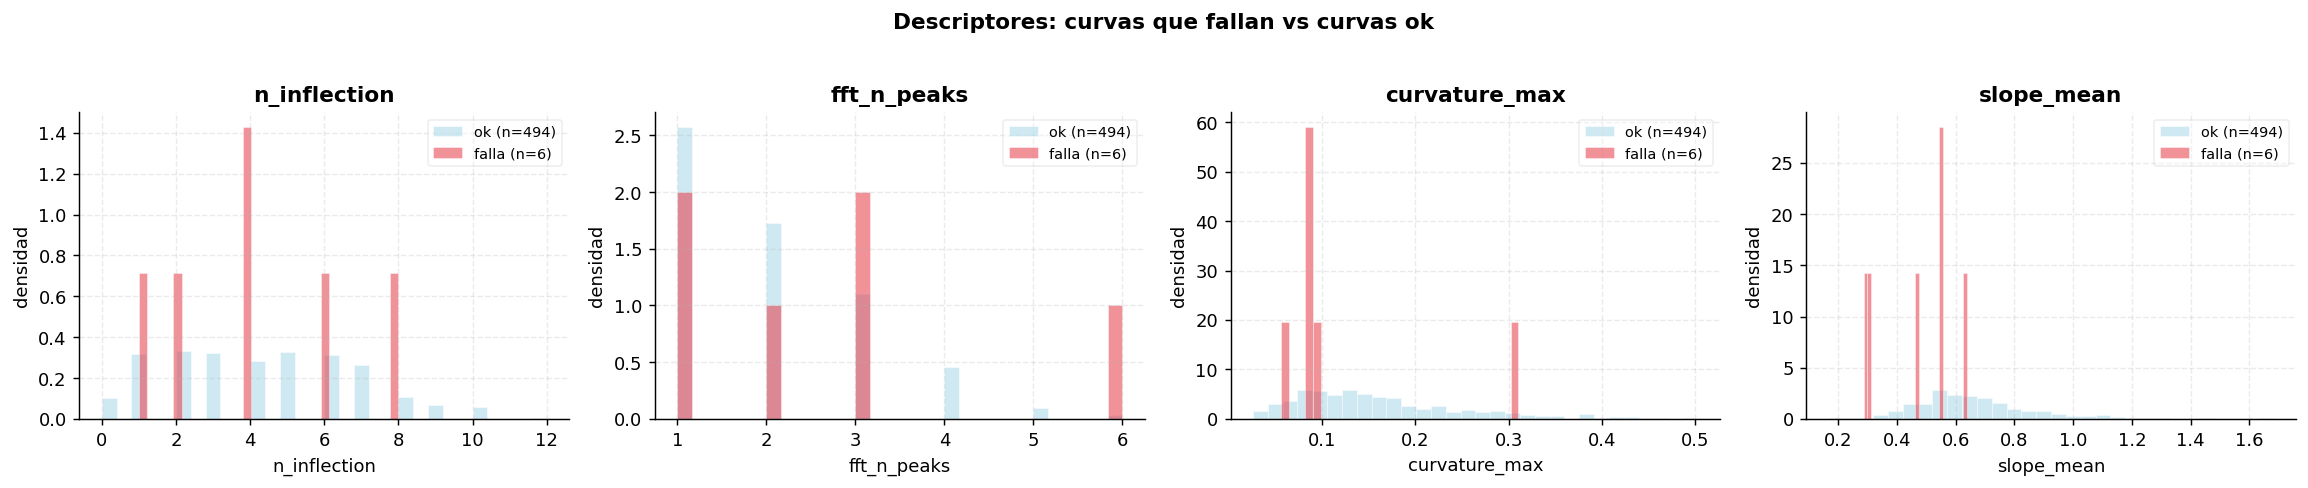

In [15]:
# Distribución de descriptores clave en curvas que fallan vs ok
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, col in zip(axes, ['n_inflection', 'fft_n_peaks', 'curvature_max', 'slope_mean']):
    for perfil, color in [('ok', AZUL_PAL), ('falla', '#E63946')]:
        vals = desc_df.loc[desc_df.perfil == perfil, col].values
        ax.hist(vals, bins=30, alpha=0.55, color=color, label=f'{perfil} (n={len(vals)})',
                density=True, edgecolor='white', linewidth=0.4)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('densidad')
    ax.legend(fontsize=8, framealpha=0.3)
fig.suptitle('Descriptores: curvas que fallan vs curvas ok', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Modos de fallo y por qué ocurren</h4>

<p style='color:#b0b0b0; font-size:0.92em'>Los fallos:</p>

<ul style='color:#b0b0b0; font-size:0.92em; line-height:1.7'>
<li><strong>Quien falla es casi siempre gaussianas</strong>. Polinomio y spline tienen tasa de fallo cercana a 0; gaussianas concentra prácticamente todos los R²&nbsp;&lt;&nbsp;0.5. La galería lo confirma: en las 6 peores reconstrucciones el método elegido es gaussianas y la curva ajustada se desploma o explota fuera del rango del target.</li>

<li><strong>Las curvas que fallan tienen muchos más puntos críticos</strong>. En el histograma de descriptores el perfil "falla" se desplaza claramente a la derecha en <code>n_inflection</code>, <code>fft_n_peaks</code> y <code>curvature_max</code>: son curvas con varias inflexiones, espectro rico y picos de curvatura altos. Justo el perfil que el selector asocia a gaussianas, pero la suma de gaussianas no es flexible cuando los picos están encimados o no son simétricos.</li>

<li><strong>El mecanismo</strong>: <code>scipy.curve_fit</code> sobre 8 campanas con valores iniciales tomados de los picos detectados en píxeles ruidosos converge a soluciones malas o no converge : y nuestro fallback es polinomio de grado 10, que sobre curvas con muchos picos también colapsa. El daño se nota más en X25 porque hay más píxeles, más picos espurios y peor inicialización.</li>

<li><strong>Por qué empeora con la escala</strong>: a más píxeles, <code>find_peaks</code> sin altura mínima absoluta detecta más máximos locales del ruido de pixelización. Eso infla <code>fft_n_peaks</code> y <code>n_maxima</code>, descriptores que el selector usa para decidir gaussianas. Más resolución termina siendo perjudicial porque alimenta el sesgo del clasificador.</li>
</ul>

<blockquote style='border-left:4px solid #F18F01; padding:10px 16px; background:rgba(241,143,1,0.10); color:#e8c97a; font-size:0.92em'>
Para reducir los fallos: (1) reentrenar el selector con descriptores calculados sobre píxeles, (2) suavizar la curva pixelizada antes de detectar picos, (3) usar un fallback más robusto cuando el ajuste gaussiano no converge : por ejemplo spline en vez de polinomio de grado 10.
</blockquote>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 4 : Juego: genera tu curva</h2>
<p style='color:#b0b0b0; font-size:0.92em'>El usuario crea una curva, la pixelizamos en las cinco escalas igual que el dataset original (multiplicar por el factor, redondear a entero, dividir de vuelta) y dejamos que el sistema adaptativo la reconstruya. Cada panel muestra la curva original, los píxeles a esa escala, la reconstrucción del método elegido y los errores frente al trazo original.</p>
<p style='color:#b0b0b0; font-size:0.92em'>Hay dos modos. El primero es trazo libre con el ratón, requiere <code>%matplotlib widget</code> (paquete <code>ipympl</code> compatible con la versión de matplotlib instalada). Si ese backend falla, el segundo modo usa sliders y funciona inline en cualquier entorno.</p>

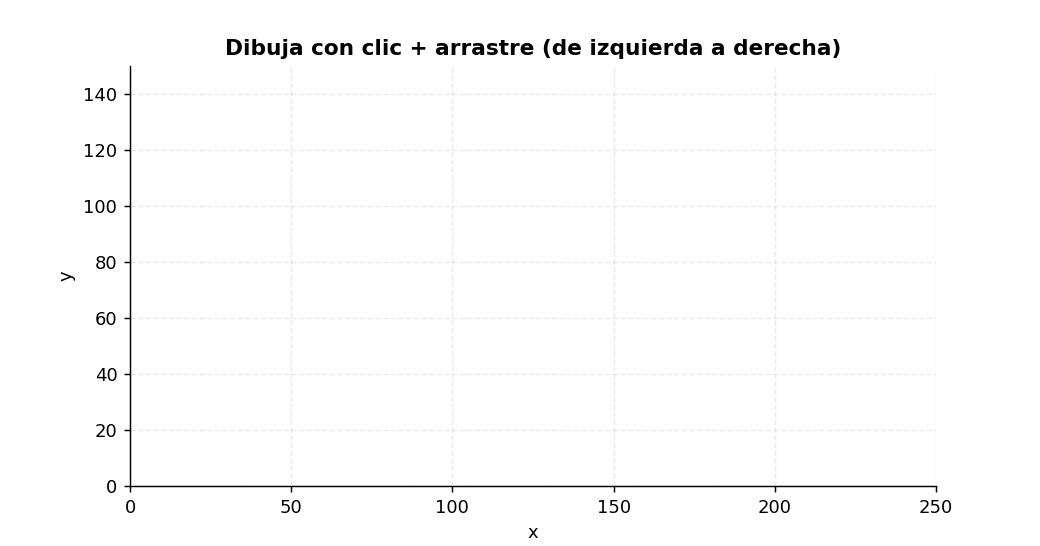

Output()

In [ ]:
#  trazo libre con el ratón. Requiere ipympl compatible con matplotlib.
DRAW_OK = False
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
    DRAW_OK = True
except Exception as e:
    print(f'Backend interactivo no disponible ({type(e).__name__}). Usar la celda de sliders más abajo.')
    print('Para activarlo: pip install -U ipympl matplotlib (versiones compatibles).')

if DRAW_OK:
    import ipywidgets as widgets
    from IPython.display import display

    SAVE_PATH = ROOT.parent / 'figuras' / 'modo1_demo.png'

    plt.ioff()
    X_MIN, X_MAX = 0.0, 250.0
    Y_MIN, Y_MAX = 0.0, 150.0

    fig_d, ax_d = plt.subplots(figsize=(8, 4.2))
    fig_d.canvas.header_visible = False
    fig_d.canvas.footer_visible = False
    fig_d.canvas.resizable = False
    ax_d.set_xlim(X_MIN, X_MAX); ax_d.set_ylim(Y_MIN, Y_MAX)
    ax_d.set_title('Dibuja con clic + arrastre (de izquierda a derecha)')
    ax_d.set_xlabel('x'); ax_d.set_ylabel('y')
    (line_d,) = ax_d.plot([], [], color=AZUL, lw=2)

    state = {'xs': [], 'ys': [], 'drawing': False}

    def _on_press(ev):
        if ev.inaxes != ax_d: return
        state['drawing'] = True
        state['xs'].clear(); state['ys'].clear()
        state['xs'].append(ev.xdata); state['ys'].append(ev.ydata)

    def _on_motion(ev):
        if not state['drawing'] or ev.inaxes != ax_d: return
        if state['xs'] and ev.xdata <= state['xs'][-1]: return
        state['xs'].append(ev.xdata); state['ys'].append(ev.ydata)
        line_d.set_data(state['xs'], state['ys']); fig_d.canvas.draw_idle()

    def _on_release(ev):
        state['drawing'] = False

    fig_d.canvas.mpl_connect('button_press_event', _on_press)
    fig_d.canvas.mpl_connect('motion_notify_event', _on_motion)
    fig_d.canvas.mpl_connect('button_release_event', _on_release)

    btn_clear = widgets.Button(description='Limpiar', button_style='warning')
    btn_run   = widgets.Button(description='Reconstruir', button_style='success')
    out_box   = widgets.Output()

    def _clear(_):
        state['xs'].clear(); state['ys'].clear()
        line_d.set_data([], []); fig_d.canvas.draw_idle()
        out_box.clear_output()
    btn_clear.on_click(_clear)

    def _pixelizar(x_real, y_real, escala):
        f = escala / 10.0
        xi = np.round(x_real * f).astype(int)
        yi = np.round(np.clip(y_real, 0, None) * f).astype(int)
        df_p = pd.DataFrame({'x': xi, 'y': yi}).drop_duplicates(subset='x').sort_values('x')
        return df_p['x'].values / f, df_p['y'].values / f

    def _reconstruir(_):
        out_box.clear_output()
        with out_box:
            if len(state['xs']) < 30:
                print('Dibuja una curva un poco más larga (>= 30 puntos).'); return
            x_user = np.array(state['xs']); y_user = np.array(state['ys'])
            ord_ = np.argsort(x_user); x_user, y_user = x_user[ord_], y_user[ord_]
            x_user, idx = np.unique(x_user, return_index=True); y_user = y_user[idx]
            x_eval = np.linspace(x_user.min(), x_user.max(), 800)
            y_true = np.interp(x_eval, x_user, y_user)
            fig_r, axes_r = plt.subplots(1, 5, figsize=(18, 3.4), sharey=True)
            for ax, esc in zip(axes_r, SCALES):
                xp, yp = _pixelizar(x_user, y_user, esc)
                if len(xp) < 5:
                    ax.set_title(f'X{esc}: insuficientes puntos'); continue
                metodo, prob = predecir_metodo(xp, yp)
                y_hat = FITTERS[metodo](xp, yp, x_eval)
                res = y_true - y_hat
                ss = ((y_true - y_true.mean())**2).sum()
                r2 = 1 - (res**2).sum() / ss if ss > 0 else float('nan')
                rmse = float(np.sqrt((res**2).mean()))
                ax.plot(x_eval, y_true, color='#e0e0e0', lw=1.6, label='tu curva')
                ax.scatter(xp, yp, s=10, color=AZUL_PAL, alpha=0.6, label=f'X{esc} ({len(xp)} px)')
                ax.plot(x_eval, y_hat, color=PALETTE[metodo], lw=1.6,
                        label=f'{metodo}\nR²={r2:.3f}  RMSE={rmse:.2f}')
                ax.set_title(f'X{esc}'); ax.set_xlabel('x')
                ax.legend(fontsize=7.5, framealpha=0.3)
            axes_r[0].set_ylabel('y')
            fig_r.suptitle('Reconstrucción de tu curva', fontsize=12, fontweight='bold', y=1.05)
            plt.tight_layout()
            fig_r.savefig(SAVE_PATH, dpi=130, bbox_inches='tight')
            plt.show()
            print(f'Guardado en {SAVE_PATH}')
    btn_run.on_click(_reconstruir)

    display(fig_d.canvas)
    display(widgets.HBox([btn_clear, btn_run]))
    display(out_box)
    plt.ion()